dataset berhasil diekstrak

ekstraksi fitur
-> folder ditemukan: /content/Dataset_Training/Dataset Preprocessing/Mentah (120 gambar)
-> folder ditemukan: /content/Dataset_Training/Dataset Preprocessing/Setengah Matang (120 gambar)
-> folder ditemukan: /content/Dataset_Training/Dataset Preprocessing/Matang (120 gambar)

 3 Percobaan Training
Percobaan 1 (Linear, C=1.0) memiliki Akurasi: 95.83%
Percobaan 2 (RBF, C=1.0) memiliki Akurasi: 94.44%
Percobaan 3 (RBF, C=10.0) memiliki Akurasi: 97.22%

Model Terbaik: Percobaan 3 (RBF, C=10.0)

Laporan Metrik Evaluasi:

                 precision    recall  f1-score   support

         Mentah       0.96      1.00      0.98        24
Setengah Matang       0.96      0.96      0.96        24
         Matang       1.00      0.96      0.98        24

       accuracy                           0.97        72
      macro avg       0.97      0.97      0.97        72
   weighted avg       0.97      0.97      0.97        72



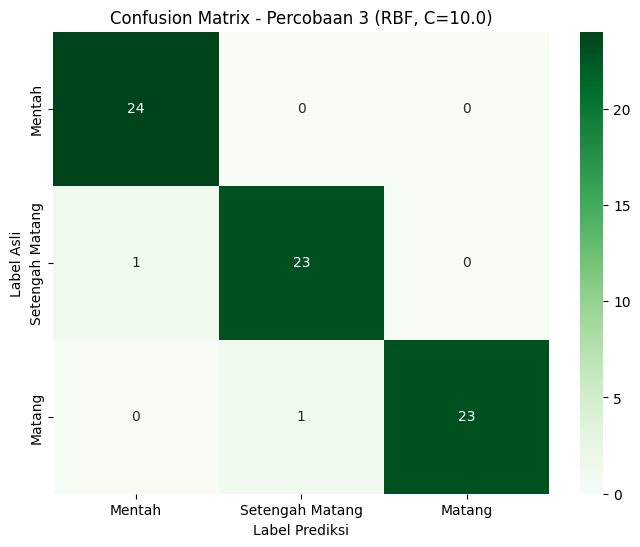

In [16]:
import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# dataset
zip_path = 'Dataset Preprocessing.zip'
extract_path = '/content/Dataset_Training'

# membersihkan folder lama jika ada dan ekstrak ulang
if os.path.exists(extract_path):
    import shutil
    shutil.rmtree(extract_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("dataset berhasil diekstrak")

# mencari definisi nama kelas
classes = ['Mentah', 'Setengah Matang', 'Matang']

# feature ekstraction hsv histogram
def get_features(img_path):
    img = cv2.imread(img_path)
    if img is None: return None
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # menghitung histogram warna dengan 8x8x8 bins
    hist = cv2.calcHist([hsv], [0, 1, 2], None, (6, 6, 6), [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

X, y = [], []
print("\nekstraksi fitur")

# pencarian folder kelas secara dinamis (Tahan terhadap perbedaan struktur zip)
for idx, cls_name in enumerate(classes):
    found_path = ""
    # mencari folder yang namanya mengandung kata kunci kelas (case-insensitive)
    keyword = cls_name.replace("_", " ").lower()

    for root, dirs, files in os.walk(extract_path):
        for d in dirs:
            if keyword in d.lower().replace("_", " "):
                found_path = os.path.join(root, d)
                break

    if found_path:
        img_list = [f for f in os.listdir(found_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"-> folder ditemukan: {found_path} ({len(img_list)} gambar)")
        for img_n in img_list:
            feat = get_features(os.path.join(found_path, img_n))
            if feat is not None:
                X.append(feat)
                y.append(idx)
    else:
        print(f"folder untuk kelas '{cls_name}' tidak ditemukan")

X, y = np.array(X), np.array(y)

# mencek apakah data berhasil dimuat
if len(X) == 0:
    raise ValueError("gagal memproses data. Pastikan isi ZIP benar dan folder tidak kosong.")

# split data dan standarisasi
X_train_r, X_test_r, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# standardScaler untuk menyamakan skala fitur agar SVM bekerja optimal
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_r)
X_test = scaler.transform(X_test_r)

# 3 skenario
scenarios = [
    {"name": "Percobaan 1 (Linear, C=1.0)", "kernel": 'linear', "C": 1.0},
    {"name": "Percobaan 2 (RBF, C=1.0)", "kernel": 'rbf', "C": 1.0},
    {"name": "Percobaan 3 (RBF, C=10.0)", "kernel": 'rbf', "C": 10.0}
]

best_model = None
best_acc = 0

print("\n 3 Percobaan Training")
for s in scenarios:
    model = SVC(kernel=s['kernel'], C=s['C'], random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{s['name']} memiliki Akurasi: {acc*100:.2f}%")

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = s['name']

# evaluasi model terbaik
y_pred_final = best_model.predict(X_test)
print(f"\nModel Terbaik: {best_name}")
print("\nLaporan Metrik Evaluasi:\n")
print(classification_report(y_test, y_pred_final, target_names=classes))

# buat visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')
plt.show()